In [111]:
from ucimlrepo import fetch_ucirepo
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

plt.style.use("ggplot")

In [112]:
#lendo o arquivo de dados
radiomic = pd.read_csv("radiomic_data_binary.csv",encoding='latin1', sep=None, engine='python')

In [113]:
radiomic

,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength,class
0,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},245a9a4dd4a20aabe9c478e95a35aa833ca20590,2D,"(1.0, 1.0)",...,0.000038,8.692009,0.962976,0.040777,0.028123,0.000123,8.843847e+06,5.416673,42.367873,BENIGN
1,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},b3a0776528a8f7438a2f6cc95486cafad01adefa,2D,"(1.0, 1.0)",...,0.000021,10.126931,0.963992,0.039417,0.002454,0.000299,4.859019e+07,14.347313,540.091956,BENIGN
2,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},f204a9caa1dea0bd0cfa97a68b8b1b98e9c45054,2D,"(1.0, 1.0)",...,0.000023,9.818248,0.882666,0.167003,0.001089,0.000951,3.526641e+06,0.706177,687.525538,BENIGN
3,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},8e7a5be028d372a7e1729e2bd28bac01c4a00a8b,2D,"(1.0, 1.0)",...,0.000021,9.865219,0.934424,0.078779,0.001812,0.000794,5.654092e+06,1.171521,381.671430,BENIGN
4,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},1e4e7e585f4bfb62c816c1b42c5215a913246ea6,2D,"(1.0, 1.0)",...,0.000013,9.779599,0.926990,0.088650,0.003791,0.000372,5.173518e+06,1.087884,213.296874,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},4d8763c6690724404fe7982a0c39afeec4361dad,2D,"(1.0, 1.0)",...,0.000022,9.497975,0.967417,0.035858,0.004763,0.000316,1.132780e+07,1.912873,122.075575,MALIGNANT
2014,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},84ac17329b823f8993d01112aa63cb0331e4fc3d,2D,"(1.0, 1.0)",...,0.000019,9.633507,0.868721,0.196504,0.001888,0.000819,1.708838e+06,0.428125,370.093192,MALIGNANT
2015,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},c160b1d530f0a59ed6033fd3a58021501ea8b3e3,2D,"(1.0, 1.0)",...,0.000010,10.351562,0.938249,0.074442,0.001593,0.000416,1.230174e+07,1.459351,408.528317,MALIGNANT
2016,v3.0.1,1.25.2,2.4.0,1.7.0,3.11.9,"{'minimumROIDimensions': 2, 'minimumROISize': ...",{'Original': {}},0f6682caf93a4e42e10fca8d447be0d71b4ccca4,2D,"(1.0, 1.0)",...,0.000017,9.756556,0.959940,0.044784,0.006686,0.000319,1.013236e+07,2.555252,130.347740,MALIGNANT


In [ ]:
#essas sao as variaveis de texto que vamos remover pois se traram de dados que nao influenciam
valores_texto = [
    'diagnostics_Versions_PyRadiomics', 
    'diagnostics_Versions_Numpy',
    'diagnostics_Versions_SimpleITK',
    'diagnostics_Versions_PyWavelet', 
    'diagnostics_Versions_Python', 
    'diagnostics_Image-original_Hash', 
    'diagnostics_Mask-original_Hash', 
    'diagnostics_Configuration_Settings', 
    'diagnostics_Configuration_EnabledImageTypes', 
'diagnostics_Image-original_Dimensionality', 
    'diagnostics_Image-original_Spacing', 
    'diagnostics_Image-original_Size', 'diagnostics_Mask-original_Spacing', 
    'diagnostics_Mask-original_Size', 
    'diagnostics_Mask-original_BoundingBox', 
    'diagnostics_Mask-original_CenterOfMassIndex', 
    'diagnostics_Mask-original_CenterOfMass'
]

radiomic = radiomic.drop(valores_texto, axis=1)

In [115]:
dupes=radiomic.duplicated()
sum(dupes)

0

In [116]:
#remoção dos duplicados se houver
radiomic_ok = radiomic.drop_duplicates(keep='first')
#Identifica registros duplicados nos dados
dupes=radiomic_ok.duplicated()
sum(dupes)

0

In [117]:
#elimina as linhas com dados ausentes
radiomic = radiomic.dropna(how='any')

Balanceando as classes, pois para conseguir resultados melhores no treino e testes é necessario

In [119]:
from sklearn.utils import resample

x = radiomic.drop("class", axis=1)
y = radiomic["class"]

# Juntando X e y para facilitar o balanceamento
df = pd.concat([x, y], axis=1)

# Separar as classes
print("Distribuição original das classes:")
print(y.value_counts())

# São duas classes chamadas 'BENIGN' e 'MALIGNANT'
df_majority = df[df['class'] == 'BENIGN']  
df_minority = df[df['class'] == 'MALIGNANT'] 

# Fazer undersampling da classe maior
df_majority_downsampled = resample(df_majority,
                                   replace=False,    # não faz repetição
                                   n_samples=len(df_minority),  # mesma quantidade da classe menor
                                   random_state=42) 

# Juntar as duas classes agora balanceadas
df_balanced = pd.concat([df_majority_downsampled, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # embaralhar

# Separar de volta x e y
x = df_balanced.drop('class', axis=1)
y = df_balanced['class']

print("\nDistribuição após balanceamento:")
print(y.value_counts())

Distribuição original das classes:
class
BENIGN       1100
MALIGNANT     918
Name: count, dtype: int64

Distribuição após balanceamento:
class
BENIGN       918
MALIGNANT    918
Name: count, dtype: int64


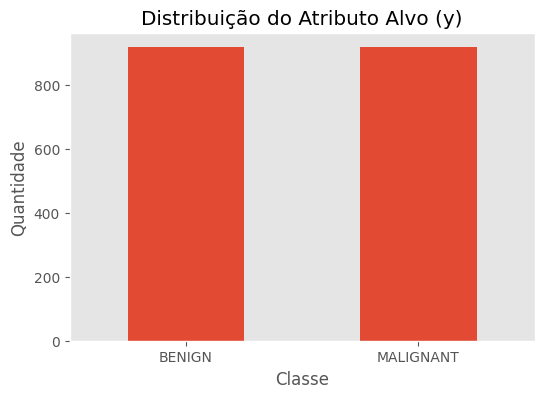

Distribuição percentual das classes:
class
BENIGN       50.0
MALIGNANT    50.0
Name: count, dtype: float64


In [120]:
# Distribuição de classes
class_counts = y.value_counts()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')
plt.title('Distribuição do Atributo Alvo (y)')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.grid(False)
plt.xticks(rotation=0)
plt.show()

# Calculo do percentual
print("Distribuição percentual das classes:")
print((class_counts / class_counts.sum()) * 100)

In [151]:
# 9. Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]}")
print(f"Teste: {X_test.shape[0]}")

Treino: 1468
Teste: 368


In [152]:
train = X_train.copy()

In [153]:
corr = train.corr()
corr.style.background_gradient(cmap='coolwarm')

/Users/alessandrabarros/Library/Python/3.9/lib/python/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/Users/alessandrabarros/Library/Python/3.9/lib/python/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


Vou remover as colunas diagnostics_Image-original_Minimum, diagnostics_Image-original_Maximum e original_firstorder_Maximum pois não tem correlação com outras colunas e não vão afetar o resultado.

Vou analisar diagnostics_Image-original_Maximum analisar as seguintes colunas: diagnostics_Image-original_Mean, diagnostics_Mask-original_VoxelNum, original_firstorder_10Percentile, original_firstorder_90Percentile	original_firstorder_Energy, original_firstorder_Kurtosis, original_firstorder_Mean	original_firstorder_Median	original_firstorder_Minimum.

Eslas tem grandes piscos de correção, mas em sua maioria tras valores muito baixo.

In [154]:
X_train = X_train.drop(['diagnostics_Image-original_Minimum', 'original_firstorder_Maximum', 'original_firstorder_Maximum'], axis=1)
X_test = X_test.drop(['diagnostics_Image-original_Minimum', 'original_firstorder_Maximum', 'original_firstorder_Maximum'], axis=1)



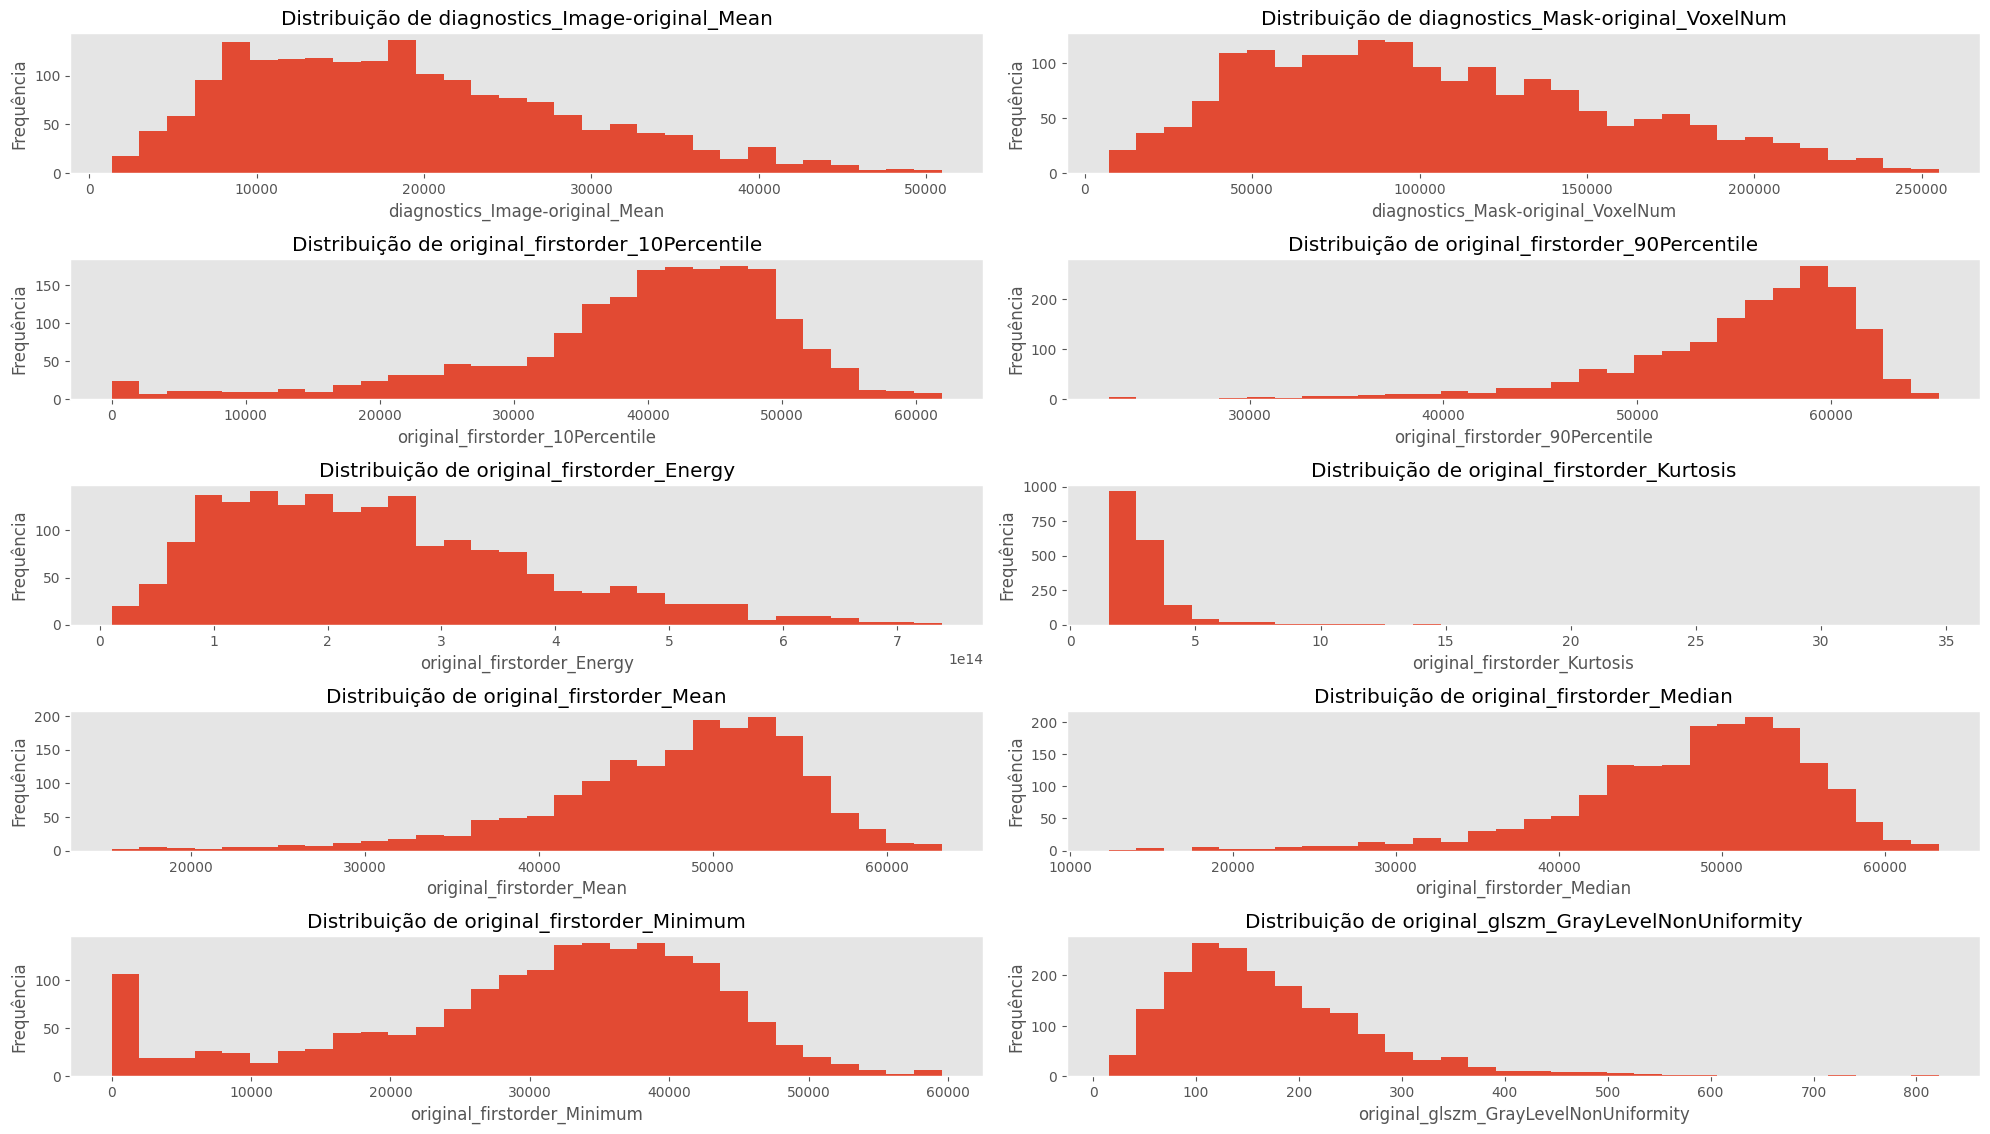

In [155]:
features = ['diagnostics_Image-original_Mean', 'diagnostics_Mask-original_VoxelNum', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile', 'original_firstorder_Energy', 'original_firstorder_Kurtosis', 'original_firstorder_Mean', 'original_firstorder_Median', 'original_firstorder_Minimum','original_glszm_GrayLevelNonUniformity']

fig, axes = plt.subplots(9, 2, figsize=(20, 20))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.hist(x[feature], bins=30)
    ax.set_title(f'Distribuição de {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequência')
    ax.grid(False)

for i in range(len(features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## Outlines

In [156]:
def detect_outliers(data, feature):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    return outliers, lower_bound, upper_bound

for feature in features:
    outliers, lower_bound, upper_bound = detect_outliers(X_train, feature)
    print(f"Feature: {feature}")
    print(f"Outliers: {outliers.shape[0]}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}\n")


Feature: diagnostics_Image-original_Mean
Outliers: 7
Lower Bound: -9976.097513198847
Upper Bound: 46355.071378707886

Feature: diagnostics_Mask-original_VoxelNum
Outliers: 0
Lower Bound: -52028.625
Upper Bound: 254938.375

Feature: original_firstorder_10Percentile
Outliers: 89
Lower Bound: 17576.375
Upper Bound: 64555.375

Feature: original_firstorder_90Percentile
Outliers: 58
Lower Bound: 42706.625
Upper Bound: 69677.625

Feature: original_firstorder_Energy
Outliers: 18
Lower Bound: -142930367926348.38
Upper Bound: 609367187021496.6

Feature: original_firstorder_Kurtosis
Outliers: 103
Lower Bound: 0.7752920067951272
Upper Bound: 4.583005001150389

Feature: original_firstorder_Mean
Outliers: 50
Lower Bound: 30680.83682690342
Upper Bound: 66576.29816263722

Feature: original_firstorder_Median
Outliers: 47
Lower Bound: 30477.875
Upper Bound: 67402.875

Feature: original_firstorder_Minimum
Outliers: 89
Lower Bound: 1426.75
Upper Bound: 62860.75

Feature: original_glszm_GrayLevelNonUniform

Não achei interessante a remoção desses outlines, se tivesse mais tempo investigaria se existe alguma combinação possivel deles que deixariam os modelos mais eficientes, analisaria individualmente ou testeria para outros valores. Fiz o teste de remoção de alguns deles, mas afeteram negativamente nos resultados.

### Tratamento de Y (target)

In [157]:
y_train.unique()


array(['BENIGN', 'MALIGNANT'], dtype=object)

Podemos perceber que 'y' tem valores do tipo string, o que não é ideal para a aplicação nos modelos. Além disso, y tem dois valores BENIGN e MALIGNANT, e para analisar os dados é ideal que eles sejam numeros, por isso:
- **BENIGN** é representado por 0.
- **MALIGNANT** é representado por 1.

In [158]:
# Remove espaços extras e pontos finais
y_train = y_train.astype(str)  


y_train = y_train.str.replace('.', '', regex=False)


y_train = y_train.map({ 'BENIGN': 0, 'MALIGNANT': 1 }).astype(int)


print(y_train.unique())

[0 1]


In [159]:
y_test.unique()

array(['MALIGNANT', 'BENIGN'], dtype=object)

In [160]:
y_test = y_test.astype(str)  


y_test = y_test.str.replace('.', '', regex=False)


y_test = y_test.map({'BENIGN': 0, 'MALIGNANT': 1}).astype(int)

print(y_test.unique())

[1 0]


In [161]:
# Escalonando usando StandardScaler
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_train = std_scaler.fit_transform(X_train)
X_test = std_scaler.transform(X_test)

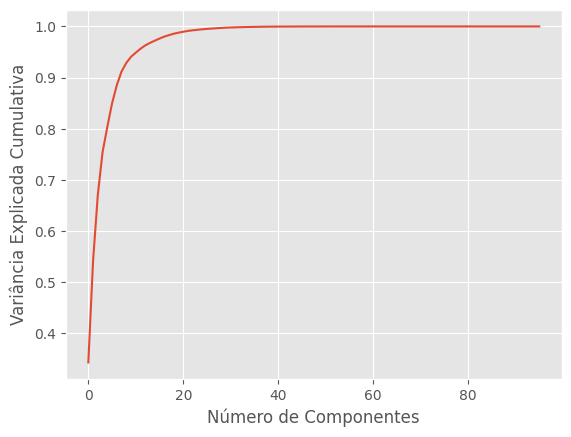

In [162]:
# Primeiro ajustar o PCA com todos os componentes já que não removemos nenhum outline
pca = PCA().fit(X_train)

# Plotar a variância acumulada
import matplotlib.pyplot as plt
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Cumulativa')
plt.show()

In [186]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


# Arvore de decisão

In [187]:
model_tree = DecisionTreeClassifier(max_depth=7, random_state=72, criterion="log_loss")
model_tree.fit(X_train_pca, y_train)

test_accuracy = model_tree.score(X_test_pca, y_test)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 63.04%


In [165]:
y_pred_dt = model_tree.predict(X_test_pca)
y_proba_dt = model_tree.predict_proba(X_test_pca)[:, 1]

In [166]:
print("\n=== Árvore de Decisão ===")
print(f"F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_proba_dt):.4f}")


=== Árvore de Decisão ===
F1-Score: 0.6531
AUC: 0.6524


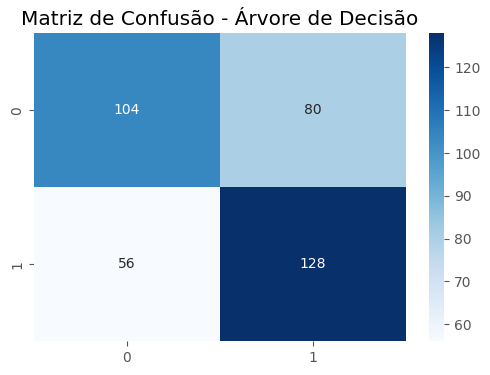


Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.57      0.60       184
           1       0.62      0.70      0.65       184

    accuracy                           0.63       368
   macro avg       0.63      0.63      0.63       368
weighted avg       0.63      0.63      0.63       368



In [167]:
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

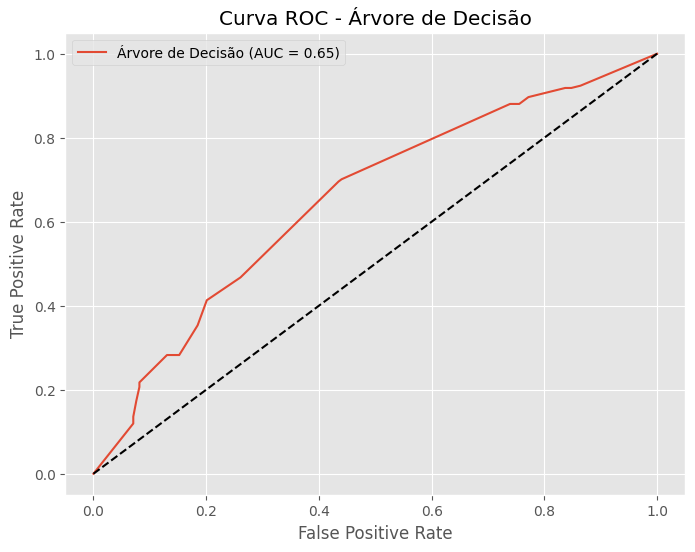

In [168]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.figure(figsize=(8,6))
plt.plot(fpr_dt, tpr_dt, label=f'Árvore de Decisão (AUC = {auc(fpr_dt, tpr_dt):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Árvore de Decisão')
plt.legend()
plt.show()

O modelo de Árvore de Decisão teve um desempenho **moderado**, mas com espaço pra melhorar. Ele acertou 63% dos casos no teste, com um F1-Score de **0.65** e AUC de **0.65**, o que mostra que está melhor que o puro chute, mas ainda longe do ideal.

Na **matriz de confusão**, ele errou bastante os benignos como malignos (80 falsos positivos), o que pode ser preocupante em contextos médicos, já que isso gera falsos alarmes. Por outro lado, foi um pouco melhor em identificar os malignos (acertou 128 de 184).

A **curva ROC** mostra como o modelo está se saindo em termos de separação entre as classes. Nesse caso, a curva ficou **relativamente próxima da linha pontilhada (linha do acaso)**, o que indica que o modelo tem uma **capacidade limitada de distinguir BENIGN de MALIGNANT**.

O **AUC = 0.65** reforça isso — é melhor do que um modelo aleatório (AUC = 0.5), mas ainda fraco. Idealmente,essa curva deveria esta mais proxima  do canto superior esquerdo, o que indicaria maior taxa de verdadeiros positivos com poucos falsos positivos.

A curva mostra que o modelo aprendeu **alguma coisa**, mas **não é confiável o suficiente para uma aplicação sensível**, como diagnóstico médico. Um modelo mais robusto pode puxar essa curva mais pra cima e dar um AUC mais alto. Assim, modelo esta começando a captar a ideia do que ele deve compreender, mas ainda esta longe de ser um modelo confiavel, principalemnte para um uso tão complicado e que lida com pessoas reais.


# MLP

In [191]:
model_mlp = MLPClassifier(hidden_layer_sizes=(100, 50), 
                    activation='relu', 
                    solver='adam',
                    max_iter=500,
                    random_state=42)
model_mlp.fit(X_train_pca, y_train)

test_accuracy = model_tree.score(X_test_pca, y_test)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 63.04%


In [192]:
# Predições
y_pred_mlp = model_mlp.predict(X_test_pca)
y_proba_mlp = model_mlp.predict_proba(X_test_pca)[:, 1]


=== MLP ===
F1-Score: 0.5744
AUC: 0.5916


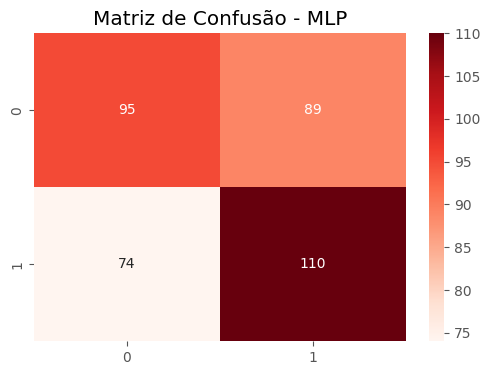

In [193]:
print("\n=== MLP ===")
print(f"F1-Score: {f1_score(y_test, y_pred_mlp):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_proba_mlp):.4f}")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusão - MLP')
plt.show()

In [173]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))


Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.52      0.54       184
           1       0.55      0.60      0.57       184

    accuracy                           0.56       368
   macro avg       0.56      0.56      0.56       368
weighted avg       0.56      0.56      0.56       368



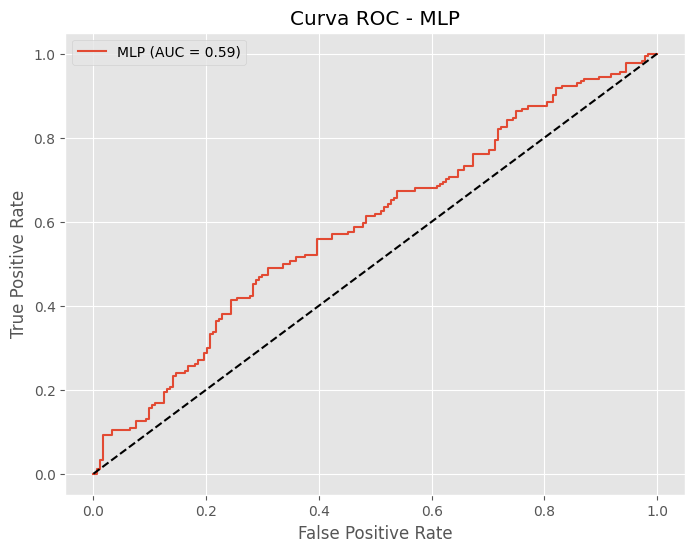

In [174]:
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_proba_mlp)
plt.figure(figsize=(8,6))
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc(fpr_mlp, tpr_mlp):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - MLP')
plt.legend()

plt.show()

Apesar da acurácia (63,04%) ser a mesma do modelo anterior (Árvore de Decisão), o desempenho do MLP foi mais fraco em quase todos os outros aspectos:

* **F1-Score (0.57)** ficou abaixo do da Árvore (0.65), indicando um equilíbrio pior entre precisão e recall.

* **Precisão** e **recall** estão bem próximos entre as classes, o que sugere que o modelo está tentando ser balanceado, mas ainda tem dificuldade em acertar os dois lados com segurança.

* **Matriz de confusão** mostra que o modelo teve bastante dificuldade em classificar corretamente a classe 0 (BENIGN), com muitos falsos positivos (89).

* **Curva ROC** está próxima da linha aleatória (AUC = 0.59), o que mostra que o MLP está com baixo poder de discriminação, praticamente chutando em algumas regiões do threshold.

# Comparação de resultados

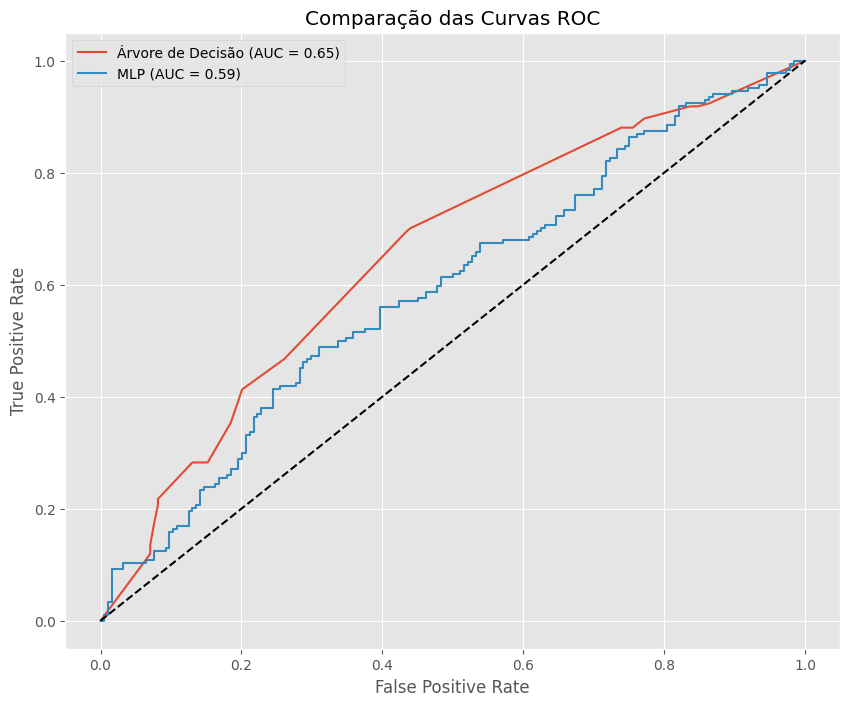

In [175]:
# Gráfico comparativo das curvas ROC
plt.figure(figsize=(10,8))
plt.plot(fpr_dt, tpr_dt, label=f'Árvore de Decisão (AUC = {auc(fpr_dt, tpr_dt):.2f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC = {auc(fpr_mlp, tpr_mlp):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparação das Curvas ROC')
plt.legend()
plt.show()



In [176]:
# Tabela comparativa
results = {
    'Modelo': ['Árvore de Decisão', 'MLP'],
    'F1-Score': [f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_mlp)],
    'AUC': [roc_auc_score(y_test, y_proba_dt), roc_auc_score(y_test, y_proba_mlp)]
}

pd.DataFrame(results).style.background_gradient(cmap='Blues')

,Modelo,F1-Score,AUC
0,Árvore de Decisão,0.653061,0.652440
1,MLP,0.574413,0.591564


O melhor modelo é o de Arvore de decisão, pois o MLP, com esses parâmetros e dados, não o conseguiu superar. O MLP Está tendo dificuldade especialmente em separar os casos benignos e malignos de forma confiável. Talvez precise de mais ajustes (número de camadas, neurônios, regularização) ou um melhor pré-processamento, já a arvore tem resultados um pouco melhores e já mais proximo a um resultado que sai da aleatoridade.